# 02. Data Preprocessing

This notebook handles all data cleaning and preparation steps 
identified during EDA. The goal is to produce a clean, 
model-ready dataset for training and evaluation.

**Steps covered:**
1. Remove duplicate rows
2. Remove invalid age entries
3. Cap extreme outliers
4. Apply log transformation
5. Impute missing values
6. Feature scaling
7. Train/test split

## 1. Import Libraries & Load Data

In [ ]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# File and metadata management
from pathlib import Path

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Suppress warnings for cleaner output
import warnings
def warn(*args, **kwargs):
    pass
warnings.warn = warn
warnings.filterwarnings("ignore")

In [13]:
# load data
df = pd.read_csv(Path("../data/cs-training.csv"), index_col=0)

print("Training data shape:", df.shape)
df.head()

Training data shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Remove Duplicate Rows

609 exact duplicate rows were identified during EDA. 
These are likely data entry errors and will be removed.

In [14]:
# Remove duplicate rows
df = df.drop_duplicates(keep='first')

# Verify removal of duplicates
print("\nNumber of rows after deduplication:", len(df))
print("Rows removed:", 150000 - len(df))


Number of rows after deduplication: 149391
Rows removed: 609


## 3. Remove Invalid Age Entries

Rows where `age = 0` are biologically impossible and represent 
data entry errors. These will be removed entirely.

In [15]:
print("Rows with age = 0:", (df['age'] == 0).sum())
df = df[df['age'] > 0]
print("Number of rows after removing age = 0:", len(df))

Rows with age = 0: 1
Number of rows after removing age = 0: 149390


## 4. Cap Outliers

Based on EDA findings, three features require outlier treatment:

- `RevolvingUtilizationOfUnsecuredLines`: Theoretically a rate 
  between 0 and 1. Values exceeding 1 are capped at 1.
- `DebtRatio`: Extreme values exceeding realistic financial 
  behaviour. Capped at the 99th percentile.

Note: Delinquency count features (`NumberOfTime30-59`, `60-89`, 
`90DaysLate`) retain their extreme values as repeated delinquency 
is plausible in real financial data.

In [16]:
# Cap RevolvingUtilization at 1
print("RevolvingUtilization > 1 before capping:", 
      (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum())

df['RevolvingUtilizationOfUnsecuredLines'] = df[
    'RevolvingUtilizationOfUnsecuredLines'].clip(upper=1)

print("RevolvingUtilization > 1 after capping:", 
      (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum())

# Cap DebtRatio at 99th percentile
debt_99 = df['DebtRatio'].quantile(0.99)
print(f"\nDebtRatio 99th percentile: {debt_99:.2f}")
print("DebtRatio > 99th pct before capping:", 
      (df['DebtRatio'] > debt_99).sum())

df['DebtRatio'] = df['DebtRatio'].clip(upper=debt_99)

print("DebtRatio > 99th pct after capping:", 
      (df['DebtRatio'] > debt_99).sum())

RevolvingUtilization > 1 before capping: 3321
RevolvingUtilization > 1 after capping: 0

DebtRatio 99th percentile: 4985.11
DebtRatio > 99th pct before capping: 1494
DebtRatio > 99th pct after capping: 0


## 5. Log Transformation — MonthlyIncome

`MonthlyIncome` is highly right-skewed with extreme high values. 
A log transformation compresses the scale and reduces the 
influence of outliers, making the distribution more suitable 
for model training.

`log1p` is used instead of `log` to safely handle zero values: 
`log1p(x) = log(1 + x)`

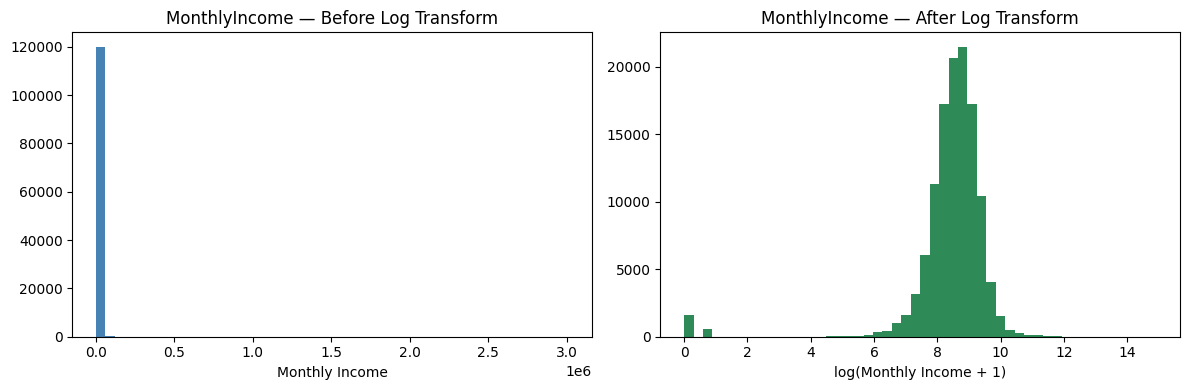

In [17]:
# Visualise before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['MonthlyIncome'].dropna(), bins=50, color='steelblue')
axes[0].set_title('MonthlyIncome — Before Log Transform')
axes[0].set_xlabel('Monthly Income')

df['MonthlyIncome'] = np.log1p(df['MonthlyIncome'])

axes[1].hist(df['MonthlyIncome'].dropna(), bins=50, color='seagreen')
axes[1].set_title('MonthlyIncome — After Log Transform')
axes[1].set_xlabel('log(Monthly Income + 1)')

plt.tight_layout()
plt.show()

## 6. Impute Missing Values

Two features contain missing values identified during EDA:

| Feature | Missing Count | Missing % | Strategy |
|---|---|---|---|
| `MonthlyIncome` | 29,731 | 19.8% | Median imputation |
| `NumberOfDependents` | 3,924 | 2.6% | Median imputation |

**Why median and not mean?**  
Both features are right-skewed with extreme values. 
The median is more robust to skew and outliers than the mean, 
making it a more representative imputation value.

In [20]:
print("Missing values before imputation:")
print(df[['MonthlyIncome', 'NumberOfDependents']].isnull().sum())

imputer = SimpleImputer(strategy='median')
df[['MonthlyIncome', 'NumberOfDependents']] = imputer.fit_transform(
    df[['MonthlyIncome', 'NumberOfDependents']]
)

print("\nMissing values after imputation:")
print(df[['MonthlyIncome', 'NumberOfDependents']].isnull().sum())

Missing values before imputation:
MonthlyIncome         29221
NumberOfDependents     3828
dtype: int64

Missing values after imputation:
MonthlyIncome         0
NumberOfDependents    0
dtype: int64


## 7. Train / Test Split

The cleaned dataset is split into training (80%) and test (20%) sets.

- **Training set**: Used to fit the model
- **Test set**: Held out entirely for final evaluation — 
  the model will never see this data during training

`random_state=42` ensures reproducibility.
`stratify=y` ensures both sets maintain the same 
class ratio (6.7% default), which is important given 
the class imbalance.

In [21]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True) * 100)
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (119512, 10)
Test set shape: (29878, 10)

Class distribution in training set:
SeriousDlqin2yrs
0    93.300254
1     6.699746
Name: proportion, dtype: float64

Class distribution in test set:
SeriousDlqin2yrs
0    93.299418
1     6.700582
Name: proportion, dtype: float64


## 8. Feature Scaling

StandardScaler standardises features to have mean = 0 
and standard deviation = 1.

**Why scale?**  
While tree-based models (Random Forest, XGBoost) are not 
sensitive to feature scale, Logistic Regression requires 
scaling for stable and accurate coefficient estimation.

**Important:** The scaler is fitted on training data only 
(`fit_transform`), then applied to test data (`transform`). 
Fitting on the full dataset would cause **data leakage** — 
the model would indirectly learn information from the test set.

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(
    X_test_scaled, columns=X_test.columns)

print("Scaling complete.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling complete.
X_train_scaled shape: (119512, 10)
X_test_scaled shape: (29878, 10)


## 9. Save Processed Data

In [24]:
output_path = Path("../data/processed")
output_path.mkdir(parents=True, exist_ok=True)

X_train_scaled.to_csv(output_path / "X_train.csv", index=False)
X_test_scaled.to_csv(output_path / "X_test.csv", index=False)
y_train.to_csv(output_path / "y_train.csv", index=False)
y_test.to_csv(output_path / "y_test.csv", index=False)

print("Processed data saved to ../data/processed/")
print("Files saved:")
print("  - X_train.csv:", X_train_scaled.shape)
print("  - X_test.csv:", X_test_scaled.shape)
print("  - y_train.csv:", y_train.shape)
print("  - y_test.csv:", y_test.shape)

Processed data saved to ../data/processed/
Files saved:
  - X_train.csv: (119512, 10)
  - X_test.csv: (29878, 10)
  - y_train.csv: (119512,)
  - y_test.csv: (29878,)


## 10. Preprocessing Summary

| Step | Action | Rows/Features Affected |
|---|---|---|
| Remove duplicates | Dropped 609 exact duplicate rows | -609 rows |
| Remove invalid age | Dropped rows where age = 0 | -1 row |
| Cap outliers | RevolvingUtilization clipped at 1 | 763 values |
| Cap outliers | DebtRatio clipped at 99th percentile | ~1,500 values |
| Log transform | Applied log1p to MonthlyIncome | 1 feature |
| Impute missing | Median imputation on MonthlyIncome & NumberOfDependents | ~33,655 values |
| Train/test split | 80% train, 20% test, stratified | — |
| Feature scaling | StandardScaler applied to all features | All 10 features |

The processed dataset is now ready for model training in `03_modeling.ipynb`.